# Anomaly Exploration

In [34]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

base_dir = Path.cwd()
for candidate in [base_dir, base_dir / "dq_pipeline" / "dq_given_data", base_dir.parent / "dq_pipeline" / "dq_given_data"]:
    if (candidate / "config.py").exists():
        os.chdir(candidate)
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import config
from data_loader import load_training_data
from feature_engineer import engineer_features

train_df = load_training_data()
engineered_df = engineer_features(train_df.copy())
final_df = pd.read_csv("output/xgb_predicted_all2.csv")

active_type_map = config.ANOMALY_TYPE_MAPS[config.ACTIVE_DATASET]
anomaly_order = [active_type_map[k] for k in sorted(active_type_map) if active_type_map[k] != "normal"]

print(f"Dataset: {config.ACTIVE_DATASET}")
print(f"Training rows: {len(train_df):,}")
print(f"Final rows: {len(final_df):,}")

  Loaded : datasets/ml_features_orders.csv
  Shape  : 503,840 rows × 38 columns
  Anomalies: 6,825 (1.35%)
Dataset: dataset2
Training rows: 503,840
Final rows: 100,768


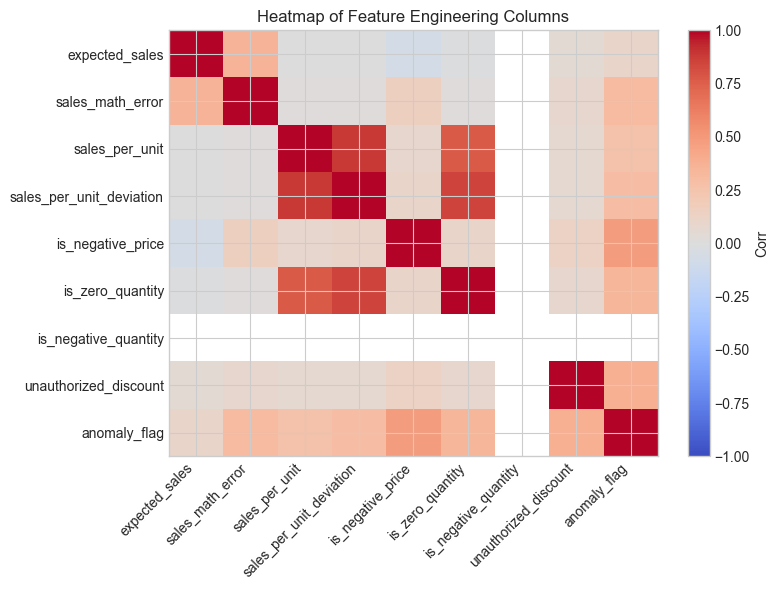

In [35]:
feature_cols = [
    "expected_sales",
    "sales_math_error",
    "sales_per_unit",
    "sales_per_unit_deviation",
    "is_negative_price",
    "is_zero_quantity",
    "is_negative_quantity",
    "unauthorized_discount",
]
feature_cols = [c for c in feature_cols if c in engineered_df.columns]
heatmap_df = engineered_df[feature_cols + [config.O_ANOMALY_FLAG]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_df.values, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Corr")
plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.title("Heatmap of Feature Engineering Columns")
plt.tight_layout()
plt.show()

anomaly_type
sales_spike            733
qty_spike              650
price_deviation        774
negative_inventory     911
promotion_mismatch    1086
combined_anomaly      1236


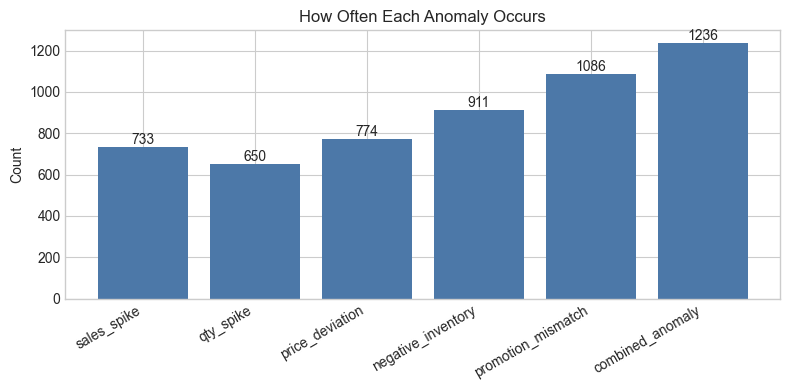

In [31]:
anomaly_counts = (
    train_df[config.O_ANOMALY_TYPE]
    .map(active_type_map)
    .fillna(train_df[config.O_ANOMALY_TYPE].astype(str))
)
anomaly_counts = anomaly_counts[anomaly_counts != "normal"].value_counts().reindex(anomaly_order, fill_value=0)

print(anomaly_counts.to_string())

plt.figure(figsize=(8, 4))
bars = plt.bar(anomaly_counts.index, anomaly_counts.values, color="#4C78A8")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("How Often Each Anomaly Occurs")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

          train_sales_spike  train_qty_spike  train_price_deviation  train_negative_inventory  train_promotion_mismatch  train_combined_anomaly  final_sales_spike  final_qty_spike  final_price_deviation  final_negative_inventory  final_promotion_mismatch  final_combined_anomaly
store_id                                                                                                                                                                                                                                                                              
S0000                     6                9                      9                         8                         6                       9                  0                0                      0                         0                         0                       0
S0001                     7                4                     11                        11                        12                      11                  0 

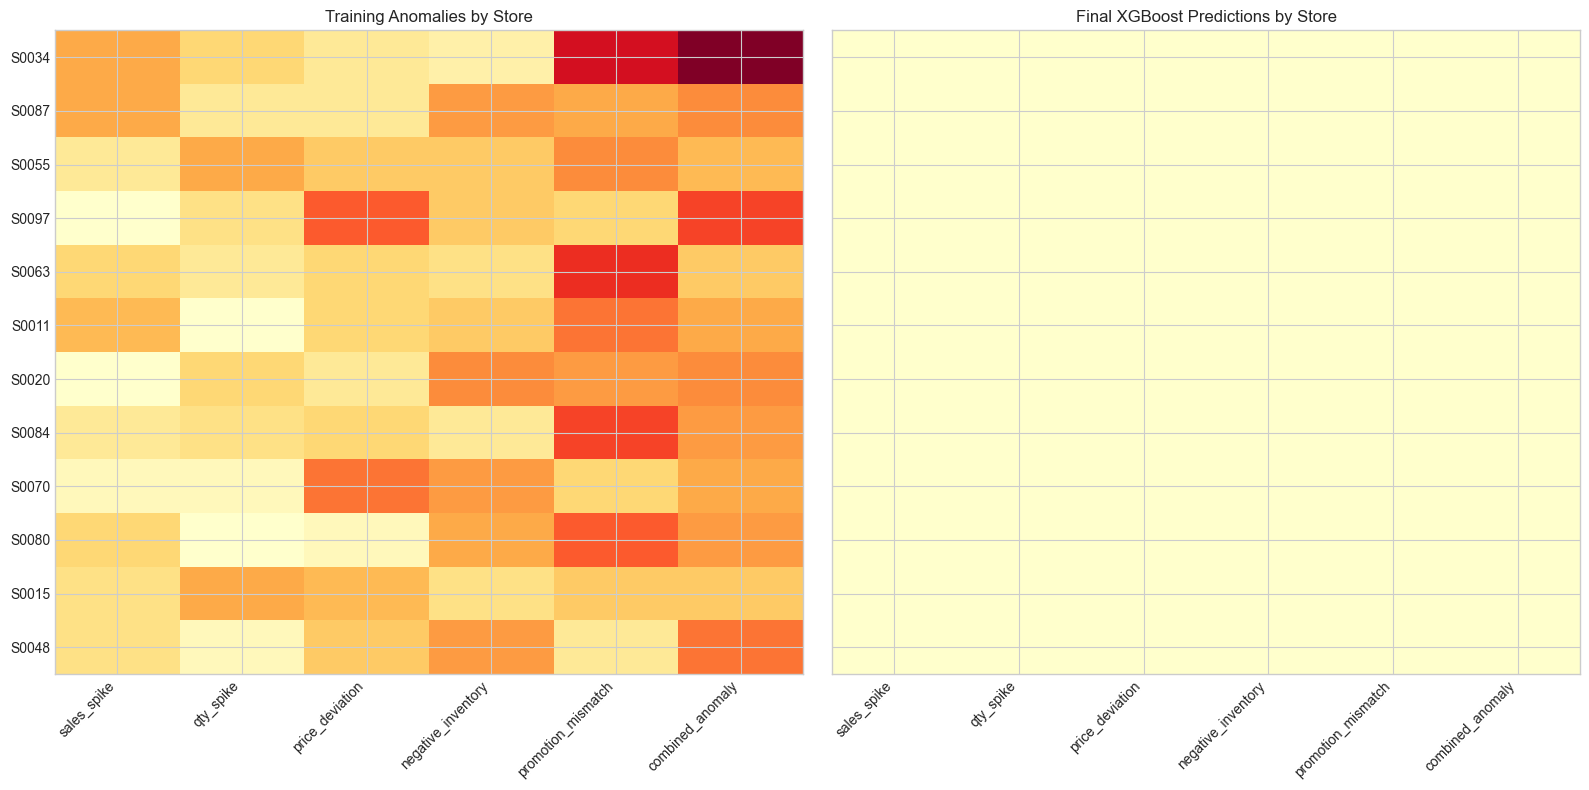

In [33]:
training_labels = train_df[config.O_ANOMALY_TYPE].map(active_type_map).fillna(train_df[config.O_ANOMALY_TYPE].astype(str))
training_labels = training_labels[training_labels != "normal"]
training_store = (
    train_df.loc[training_labels.index]
    .assign(anomaly_label=training_labels)
    .groupby(["store_id", "anomaly_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=anomaly_order, fill_value=0)
)

if "predicted_type" in final_df.columns:
    final_labels = final_df["predicted_type"].fillna("unknown")
    final_labels = final_labels[final_labels != "normal"]
    final_store = (
        final_df.loc[final_labels.index]
        .groupby(["store_id", final_labels])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=anomaly_order, fill_value=0)
    )
else:
    final_store = pd.DataFrame(0, index=training_store.index, columns=anomaly_order)

store_compare = training_store.add_prefix("train_").join(final_store.add_prefix("final_"), how="outer").fillna(0)

print(store_compare.head(15).to_string())

sample_stores = training_store.sum(axis=1).sort_values(ascending=False).head(12).index
train_plot = training_store.loc[sample_stores]
final_plot = final_store.reindex(sample_stores).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
for ax, plot_df, title in [
    (axes[0], train_plot, "Training Anomalies by Store"),
    (axes[1], final_plot, "Final XGBoost Predictions by Store"),
]:
    ax.imshow(plot_df.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(plot_df.columns)))
    ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(plot_df.index)))
    ax.set_yticklabels(plot_df.index)
    ax.set_title(title)

plt.tight_layout()
plt.show()